## Assignment 3: Understanding data and relationships between data

In lab 1 and 2 you learnt how to work with datasets in tersm of manipulating data and visualisations. Even though visualizations help us to get meaningful informations from data, sometimes, when the dataset has a lot of variables(e.g.>10 columns) is hard to decide what data to plot first and why do to so. 

Thus, a key to get relevant information from the data is to acctualy understand some statistics concepts.

For this lab, the tutorial is merged with the assigment, creating a hands-on guide to follow and use your thinking to answer some questions.

# IMPORTANT!
PLEASE TRY TO NOT USE AI(e.g.chat GPT) to answer the questions. What will be graded is your capacity to make a logical reasoning and explain your answer, regardless of its 100% correctness.

The structure of this notebook is:
- Part 1: Understand correlation, covariance, and standard deviation in data
- Part 2: PCA (Principal component analysis)
- Part 3: Your turn

# Part 1

### 1. What is correlation and why is it useful?
In statistics, correlation is a way to capture a linear relationship between two quantitative variables and it is measured by a correlation coefficient. 

Below you have some code that creates 4 variables with difffrent relationships. Your task is to answer the questions.

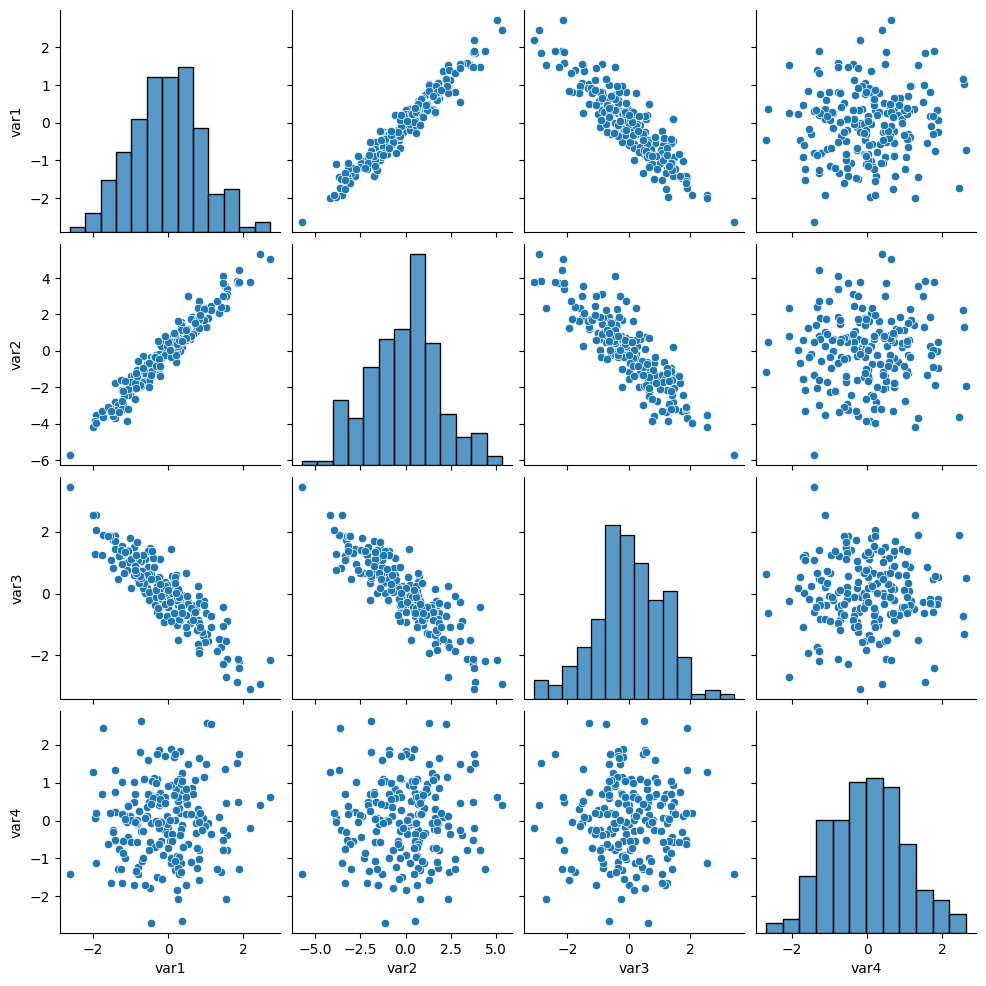

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 200
var1 = np.random.normal(0,1,n)
var2 = 2*var1 + np.random.normal(0,0.5,n) # strong positive correlation     
var3 = -var1 + np.random.normal(0,0.5,n)  # strong negative correlation    
var4 = np.random.normal(0,1,n)            # no correlation

df = pd.DataFrame({
    "var1": var1,
    "var2": var2,
    "var3": var3,
    "var4": var4
})

sns.pairplot(df)
plt.show()

#### (0.25 points) Questions: 
- Based on the plots, which variables do you think are correlated and which are not?
- Are there any visual patterns what made you decide their correlation?

#### (your answer here)

#### Correlation matrix
Correlation between variables can be represented using a correlation matrix. The code below computes the correlation coefficient for the above variables and displays the results using a heatmap.

          var1      var2      var3      var4
var1  1.000000  0.968446 -0.896690  0.065398
var2  0.968446  1.000000 -0.870616  0.036391
var3 -0.896690 -0.870616  1.000000 -0.007389
var4  0.065398  0.036391 -0.007389  1.000000


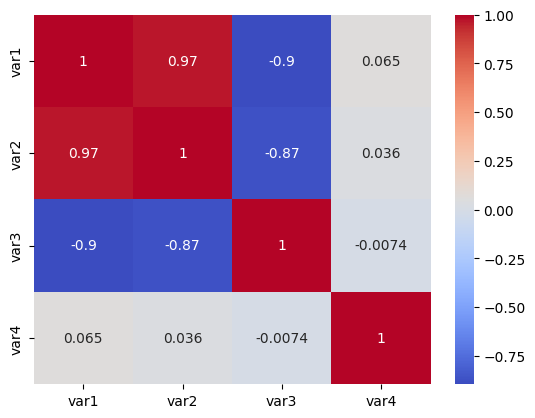

In [2]:
corr = df.corr()
print(corr)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

#### (0.25 points) Questions:
- Which pair has the highest correlation?
- Which pair has near-zero correlation?
- What does a positive correlation mean?
- What does a negative correlation mean?

#### (your answers here)

Two of the most used correlation coefficients are Pearson Correaltion and Spearman's Rank Correaltion. Pearson is used to measure linear relationships between two continuous variables, while Spearman's Rank Correlation measures monotonic relationships in data (usually orinal and non-linear data).

**Pearson correlation coefficient** formula is:

## $\rho_{x,y} = \frac{cov(x,y)}{\sigma_x \sigma_y}$ ##

where:

- cov(x,y) = covariance between x and y  
- **$\sigma_x$** = standard deviation of x  
- **$\sigma_y$** = standard deviation of y

Where the standard deviation measures how spread out a variable is around its mean and the covariance measures how two variables change together

Pearson coefficient takes vales in [-1, 1], where:

- 1 = perfect positive relationship 
- 0 = no linear relationship
- -1 = perfect negative relationship

#### (0.25 points) Questions:
- What does a small and a large standard deviation mean?
- What does a positive and a negative covariance mean?
- If covariance measures how a pair of variable changes (the liniar relationship between them), 
why do you think that it's now enough to use covariance as a correlation coefficient? Do you think anout
any reason why in Pearson's formula covariance is divided by the standard deviation? You can argument your answer using a concrete example.

#### (your answers here)

### Why are we interested to see correlation in data?
Short answer: highly correlated data doesn't provide much information during learning for a ML algorithm. 

If you think about your previous assignment, you had a task to implement some feature engineering. Well, feature engineering is not made at random, and incredibly few of you actually computed a correlation matrix to see which features are correlated and not and based your decisions on that. 

As an ofen seen practice, when you have highly correlated values you either drop some of them, or combined them in one single new feature and drop the original ones. 

# Part 2

### Principal Component Analysis (PCA)
Now that you have a better undestanding about data correlation, let's see what PCA is.

PCA is a dimensionality reduction technique and helps us to reduce the number of features in a dataset, but it keeps the most important information. It changes large and complex datasets by transforming correlated features into a smaller set of uncorrelated features, called components.

Shortly, it:
- removes redundancy in data
- make data easier to visualize
- improve computational efficienty
- provide a better input for ML regression, classification or clustering algorithms

**How PCA works?**
1. Data must be standardize to have a mean of 0 and a standard deviation of 1
2. Calculate covariance matrix
3. Find the Principal Components (PC1, PC2, ..., PCn)
4. Pick the best top k directions and transform data by projecting each point on the new components

**3. What principal components represent?**
- PC1 = the direction of maximum variance of data (the direction in which data is spread the most)
- PC2 = the next best direction where data is spread the most. This direction is perpendicular on the first)
- PC3, ..., PCn = the next best directions 

**4. Based on what to pick top k directions?**
When deciding how many compoents we should consider, a practice is to pick as many as needed such that they capture a high variance (e.g.95%)

#### (0.25 points) Question: 
- Why do you think that applying PCA can reduce the noise in data and sometimes helps to avoid overfitting?

#### (your answer here)

### Example of applying PCA
PCA is an unsepervised ML algorithm and you can use it's already implemented version from libraries as sklearn.

Below, we will train a model without using PCA and then we'll apply PCA to see if it can help the performance

In [3]:
from sklearn.datasets import load_wine
import pandas as pd

data = load_wine()

x = data.data
y = data.target # target has 3 possible classses (wine regions)
df = pd.DataFrame(x, columns=data.feature_names)
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


                               alcohol  malic_acid       ash  \
alcohol                       1.000000    0.094397  0.211545   
malic_acid                    0.094397    1.000000  0.164045   
ash                           0.211545    0.164045  1.000000   
alcalinity_of_ash            -0.310235    0.288500  0.443367   
magnesium                     0.270798   -0.054575  0.286587   
total_phenols                 0.289101   -0.335167  0.128980   
flavanoids                    0.236815   -0.411007  0.115077   
nonflavanoid_phenols         -0.155929    0.292977  0.186230   
proanthocyanins               0.136698   -0.220746  0.009652   
color_intensity               0.546364    0.248985  0.258887   
hue                          -0.071747   -0.561296 -0.074667   
od280/od315_of_diluted_wines  0.072343   -0.368710  0.003911   
proline                       0.643720   -0.192011  0.223626   

                              alcalinity_of_ash  magnesium  total_phenols  \
alcohol                   

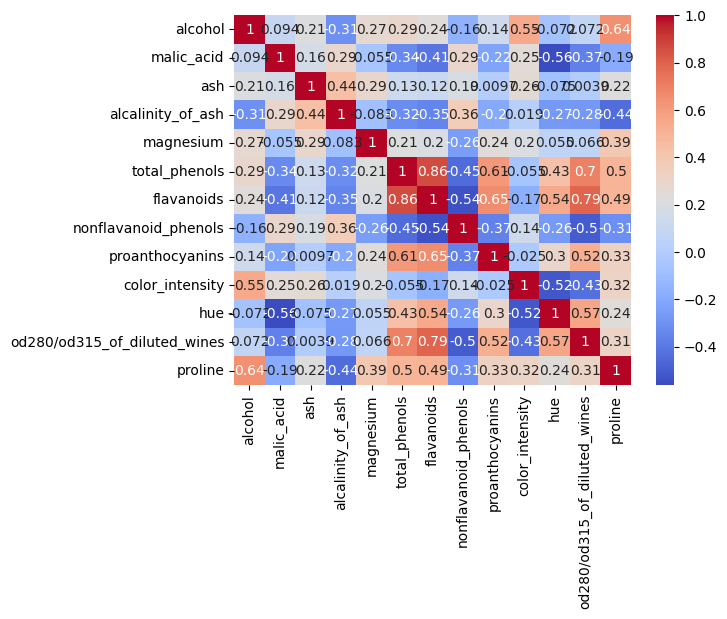

In [4]:
corr = df.corr()
print(corr)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LogisticRegression(max_iter=500)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9814814814814815


#### Apply PCA for the same model and data

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)
print(pca.explained_variance_ratio_)

[0.36196226 0.18763862]


Having two values in the output means that PCA found 2 componets, thus it reduces the dimention from 13 to 2. The sum of the two elements in the above list represent the total variance that was kept, thus ~55%

In [8]:
model_pca = LogisticRegression(max_iter=500)
model_pca.fit(x_train_pca, y_train)
y_pred_pca = model_pca.predict(x_test_pca)

print("Accuracy with PCA:", accuracy_score(y_test, y_pred_pca))

Accuracy with PCA: 0.9629629629629629


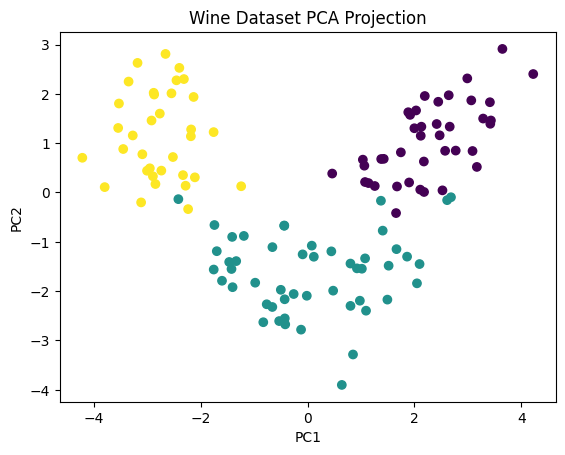

In [9]:
# plot PCA data
import matplotlib.pyplot as plt

plt.scatter(x_train_pca[:,0], x_train_pca[:,1], c=y_train)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine Dataset PCA Projection")

plt.show()

This was a toy example with a small dataset. In small datasets with few features, PCA often does not help to much. But when you have let's say 1000 feaatures it can succesfully reduce them to <100 for example, while keeping the important information.

In [10]:
# we can test with a diffrent number of components 
for k in [2, 5, 10]:
    pca = PCA(n_components=k)   
    x_pca = pca.fit_transform(x_train_scaled)
    model.fit(x_train_pca, y_train)
    y_pred_pca = model_pca.predict(x_test_pca)
    print(f"Accuracy with PCA with {k} components:", accuracy_score(y_test, y_pred_pca))

Accuracy with PCA with 2 components: 0.9629629629629629
Accuracy with PCA with 5 components: 0.9629629629629629
Accuracy with PCA with 10 components: 0.9629629629629629


In [11]:
#To automatically find the minimum number of compoents that explain 95% of variance you can use
pca = PCA(n_components=0.95)
x_pca = pca.fit_transform(x_train_scaled)

print(pca.n_components_)

10


#### (0.25 points) Final Questions:
- What could be some reasons why the accuracy after using PCA on the above example is a little lower than without using it?
- Havong a lot of feature in your dataset, for which of the following ML algorithms would you think applying PCA in the pre-processing step could help? Is there any algorithm for which you would not want to apply PCA in pre-processing part? Argument your answer. The ML alforithms you can pick from are: Linear/Logistic Regression, SVM, Decision Trees, Random Forests

#### (your answer here)

 # Part 3: your turn (deadline week 4. Every week delay is penalized with 3 points. Maximum 2 delays)

Choose a dataset from the list below (a dataset with at lest 50 initial features (columns)) and try to undersatand the data. You can use the knowledge gained during lab1 and lab2 for this. Additionally you have to study data relationships (correlation) and study if PCA can help you in solving your problem. You can pick either a classification, regression or clustering problem.

Datasets:
* Year prediction dataset: https://archive.ics.uci.edu/dataset/203/yearpredictionmsd
* Credit risk dataset: https://www.kaggle.com/competitions/home-credit-default-risk/data
* Lending club loan dataset: https://www.kaggle.com/datasets/wordsforthewise/lending-club
  

### Task 1: Data loading and exploration (1 point)
- Do it efficient (like using polars)
- Explore data, statistics, outliers etc
    
### Task 2: Calculate the correlation matrix (1 point)
- Provide a correlation matrix for data and interpret it. Explain which data is correlated and how you can use that information
     
### Task 3: Try to do some feature engineering on your own (2 points)
- Use the correlation information to do some feature engineering such that you remove as most correlated as possible (you are free to explore and use your creativity and thinking for this)
- For all decision you make while doing feature engineering you have to explain in words why you did what you did. Explain what was the hardest thing to do
    
### Task 4: Train a ML model for your problem (1.5 point)
- Split data in train/test (80-20)
- Pick a ML model (argument your choice)
- Train the model
- Compute performance metrics
    
### Task 5: Apply PCA instead of your feature engineering (2 points)
- Apply PCA to your dataset instead of doing feature engineering on your own
- Try multiple values for the number of components
- Visualise data after applying PCA
    
### Task 6: Train the same ML model, but with PCA features (1.5 point)
- Train the previous model on the same data split
- Compute performance metrics and compare them with the metrics obtained before using PCA
- What do you observe? Discuss and do a comparative analysis of the two approaces